### <b><font color='saddlebrown'>Прогнозирование</font></b>

##### <b><font color='saddlebrown'>1. Модель ARIMA</font></b>

In [1]:
# мпорт библиотек
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.datasets import get_rdataset
import matplotlib.pyplot as plt

In [2]:
# Загрузка данных
df_air = get_rdataset('AirPassengers').data
df_air.index = pd.date_range(start = '1949-01',
                            periods = len(df_air.index),
                            freq = 'ME').to_period()
df_air.index = df_air.index.to_timestamp()
df_air.head(3)

,time,value
1949-01-01,1949.000000,112
1949-02-01,1949.083333,118
1949-03-01,1949.166667,132


In [3]:
# Определяем модель ARIMA
# p - компонент авторегрессии (кол-во предыдущих значений)
# d - интегральный компонент (кол-во раз, которое необходимо продифференцировать данные)
# q - компонент скользящего среднего (сколько прошлых членов ошибки используется для прогнозирования)
model_arima = ARIMA(df_air['value'], order = (5, 1, 0)) # (p,d,q)

In [4]:
# Подгонка модели
model_arima_fit = model_arima.fit()

In [5]:
# Вывод итогов
print(model_arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  144
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -689.067
Date:                Fri, 05 Jun 2026   AIC                           1390.135
Time:                        09:48:42   BIC                           1407.912
Sample:                    01-01-1949   HQIC                          1397.358
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3223      0.097      3.334      0.001       0.133       0.512
ar.L2         -0.2170      0.078     -2.776      0.006      -0.370      -0.064
ar.L3         -0.0646      0.071     -0.915      0.3

In [6]:
# Прогнозирование
forecast_arima = model_arima_fit.forecast(steps = 12) # сколько периодов вперед спрогнозировать

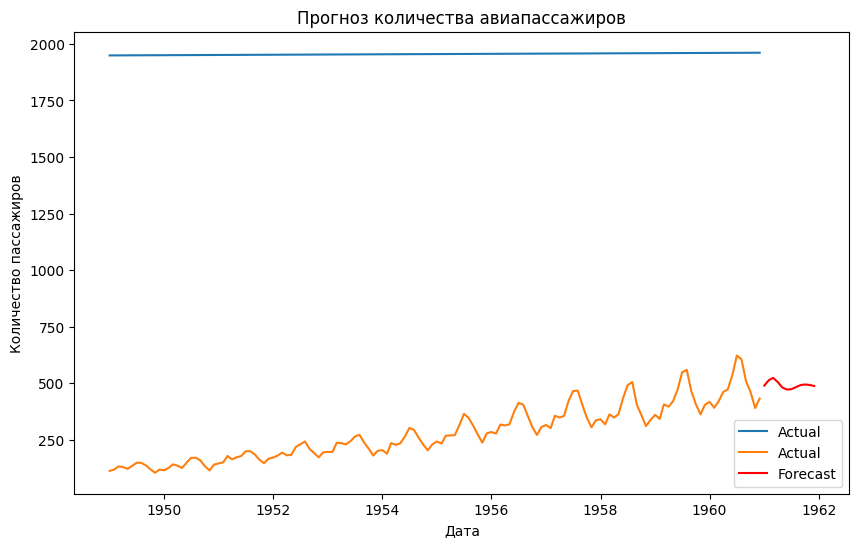

In [7]:
# Построение графика результатов
plt.figure(figsize = (10, 6))
plt.plot(df_air, label = 'Actual')
plt.plot(forecast_arima, label = 'Forecast', color = 'red')
plt.title('Прогноз количества авиапассажиров')
plt.xlabel('Дата')
plt.ylabel('Количество пассажиров')
plt.legend()
plt.show()

##### <b><font color='saddlebrown'>2. Оценка модели</font></b>

In [8]:
# Удаление невостребованного столбца
del df_air['time']

In [9]:
# Разделение данных на обучающий и тестовые наборы
train_size = int(len(df_air) * 0.8)
train, test = df_air[0:train_size], df_air[train_size:]

In [10]:
# Подбор модели ARIMA
model_arima = ARIMA(train, order = (12, 2, 6))
model_arima_fit = model_arima.fit()

c:\Users\Vitaliy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Vitaliy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Vitaliy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [11]:
# Прогнозы
predictions_arima = model_arima_fit.forecast(steps = len(test))

In [12]:
# Расчет mse и rmse
from sklearn.metrics import mean_squared_error
from math import sqrt
mse = mean_squared_error(test, predictions_arima)
print('Среднеквадратичная ошибка:', mse)

rmse = sqrt(mse)
print('Root Mean Squared Error:', rmse)

Среднеквадратичная ошибка: 1002.3560742365082
Root Mean Squared Error: 31.660007489520723


In [13]:
from pmdarima import auto_arima

model = auto_arima(df_air['value'], seasonal=True, m=12)
print(model.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  144
Model:             SARIMAX(2, 1, 1)x(0, 1, [], 12)   Log Likelihood                -504.923
Date:                             Fri, 05 Jun 2026   AIC                           1017.847
Time:                                     09:48:51   BIC                           1029.348
Sample:                                 01-01-1949   HQIC                          1022.520
                                      - 12-01-1960                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5960      0.085      6.987      0.000       0.429       0.763
ar.L2          0.2143      

Выводы:<br>
В среднем прогноз ARIMA(5,1,0) ошибается примерно на 80 тыс. пассажиров в месяц.<br>
Относительная ошибка: RMSE/среднее значение ряда * 100% = 28.8%<br>
Ошибка примерно 29% от среднего уровня — это довольно большая ошибка, то есть модель ARIMA(5,1,0) не идеально предсказывает данные.

In [14]:
rmse/test.mean()

value    0.071904
dtype: float64

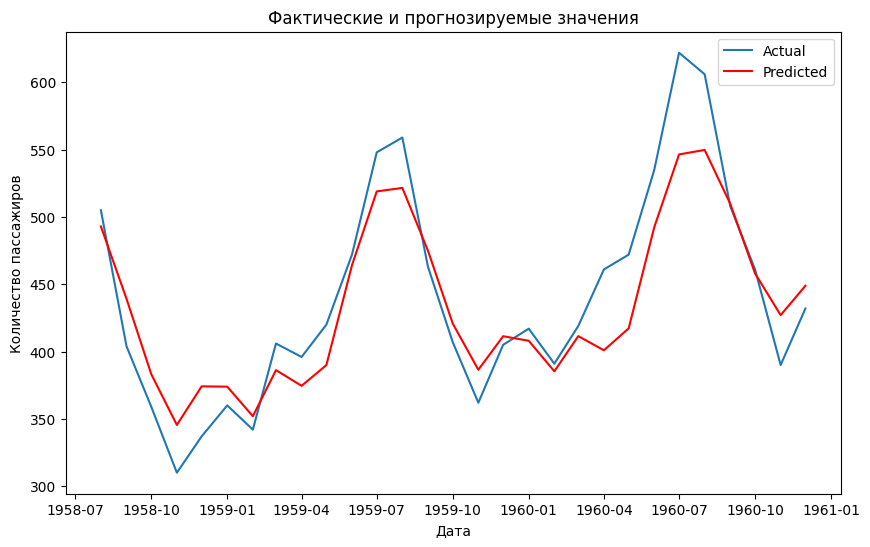

In [15]:
# Построение графика сравнения фактических и прогнозируемых значений
plt.figure(figsize = (10, 6))
plt.plot(test.index, test, label = 'Actual')
plt.plot(test.index, predictions_arima, label = 'Predicted', color = 'red')
plt.title('Фактические и прогнозируемые значения')
plt.xlabel('Дата')
plt.ylabel('Количество пассажиров')
plt.legend()
plt.show()

##### <b><font color='saddlebrown'>3. Модель SARIMA</font></b>

In [16]:
# мпорт необходимого модуля
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [17]:
# Определение модели Sarima
model_sarima = SARIMAX(df_air, order = (9, 2, 6), seasonal_order = (6, 2, 6, 12))

In [18]:
# Тренировка модели
model_sarima_fit = model_sarima.fit(disp = False)

c:\Users\Vitaliy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\Vitaliy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [19]:
# Вывод итогового значения модели
print(model_sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              value   No. Observations:                  144
Model:             SARIMAX(9, 2, 6)x(6, 2, 6, 12)   Log Likelihood                -450.043
Date:                            Fri, 05 Jun 2026   AIC                            956.087
Time:                                    09:50:24   BIC                           1033.666
Sample:                                01-01-1949   HQIC                           987.586
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -2.2452      0.829     -2.708      0.007      -3.870      -0.620
ar.L2         -3.0531      1.133   

In [20]:
# Прогнозирование
forecast_sarima = model_sarima_fit.forecast(steps = 12)

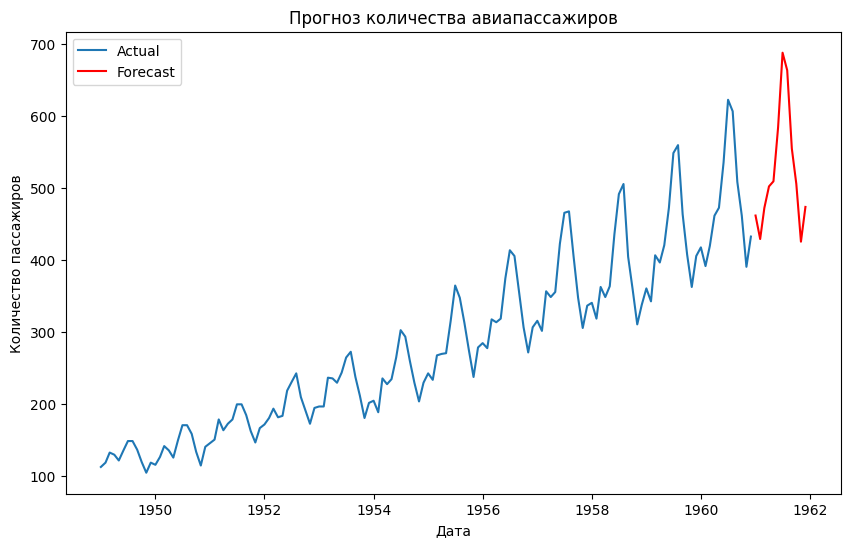

In [21]:
# Построение графика результатов
plt.figure(figsize = (10, 6))
plt.plot(df_air, label = 'Actual')
plt.plot(forecast_sarima, label = 'Forecast', color = 'red')
plt.title('Прогноз количества авиапассажиров')
plt.xlabel('Дата')
plt.ylabel('Количество пассажиров')
plt.legend()
plt.show()

Оцените модель SARIMA

In [22]:
# Обучите модель SARIMA на тренировочных данных
train_size = int(len(df_air) * 0.8)
train, test = df_air[0:train_size], df_air[train_size:]
model_sarima = SARIMAX(train, order = (9, 2, 6), seasonal_order = (6, 2, 6, 12))
model_sarima_fit = model_sarima.fit(disp=False)

c:\Users\Vitaliy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\Vitaliy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [23]:
# Постройте прогнозы
predictions_sarima = model_sarima_fit.forecast(steps = len(test))



In [24]:
# Расчитайте mse и rmse
import numpy as np
mse = mean_squared_error(test, predictions_sarima)
rmse = np.sqrt(mse)
print('Среднеквадратичная ошибка:', mse)
print('Корень из среднеквадратичной ошибки:', rmse)


Среднеквадратичная ошибка: 2796.020147412437
Корень из среднеквадратичной ошибки: 52.877406776547176


In [25]:
rmse/test.mean()

value    0.120091
dtype: float64

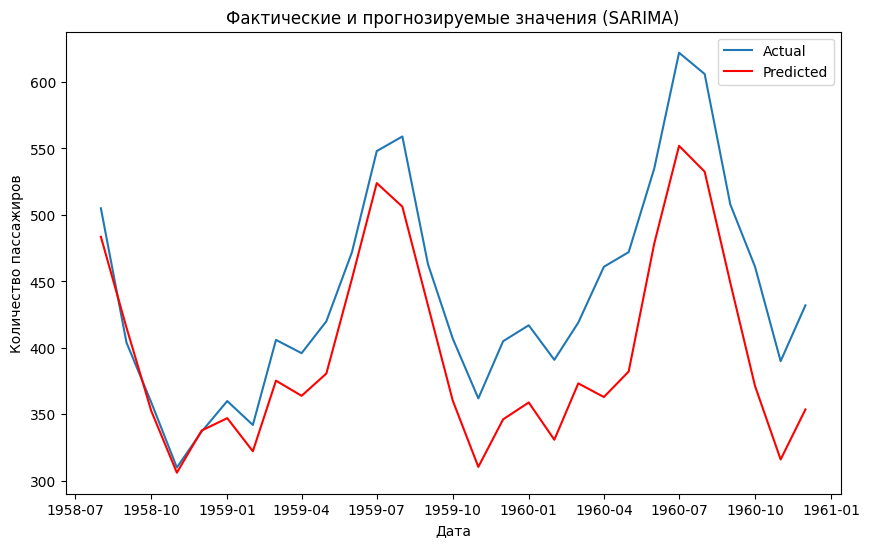

In [26]:
# Постройте график сравнения фактических и прогнозируемых значений
plt.figure(figsize = (10, 6))
plt.plot(test.index, test, label = 'Actual')
plt.plot(test.index, predictions_sarima, label = 'Predicted', color = 'red')
plt.title('Фактические и прогнозируемые значения (SARIMA)')
plt.xlabel('Дата')
plt.ylabel('Количество пассажиров')
plt.legend()
plt.show()



##### <b><font color='saddlebrown'>4. Модель Prophet</font></b>

In [27]:
# мпорт необходимого модуля
from prophet import Prophet

In [28]:
# Prophet требует, чтобы столбцы были названы 'ds' (дата) и 'y' (значение).
df_air.reset_index(inplace = True)
df_air.columns = ['ds', 'y']

In [29]:
# Создание экземпляра Prophet
model_prophet = Prophet()

In [30]:
# Тренировка модели
model_prophet.fit(df_air)

09:51:39 - cmdstanpy - INFO - Chain [1] start processing
09:51:39 - cmdstanpy - INFO - Chain [1] done processing


In [31]:
# Создание фрейма данных для хранения прогнозов
future = model_prophet.make_future_dataframe(periods = 12, freq = 'ME')

In [32]:
# Делаем прогнозы
forecast = model_prophet.predict(future)

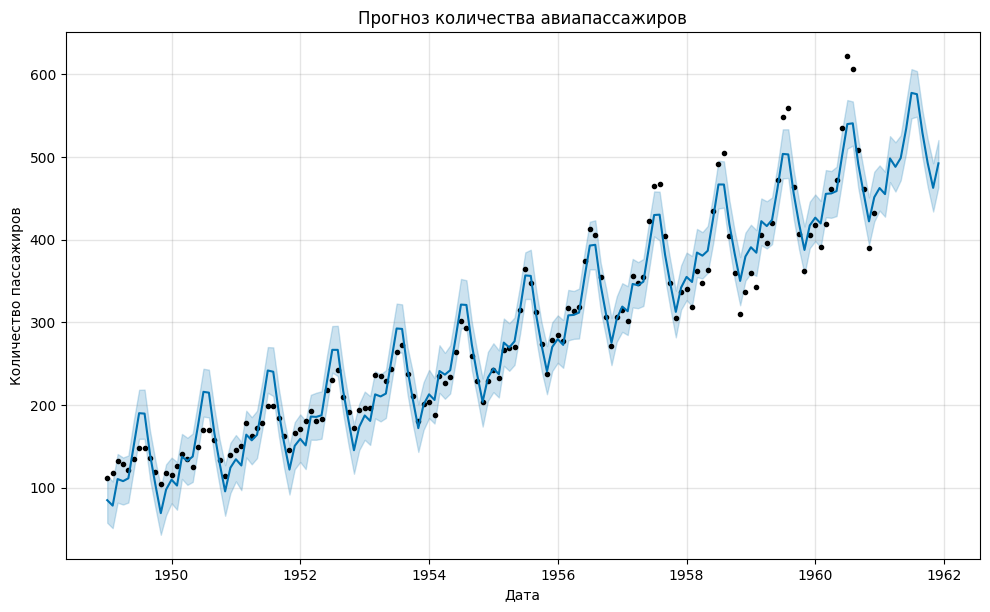

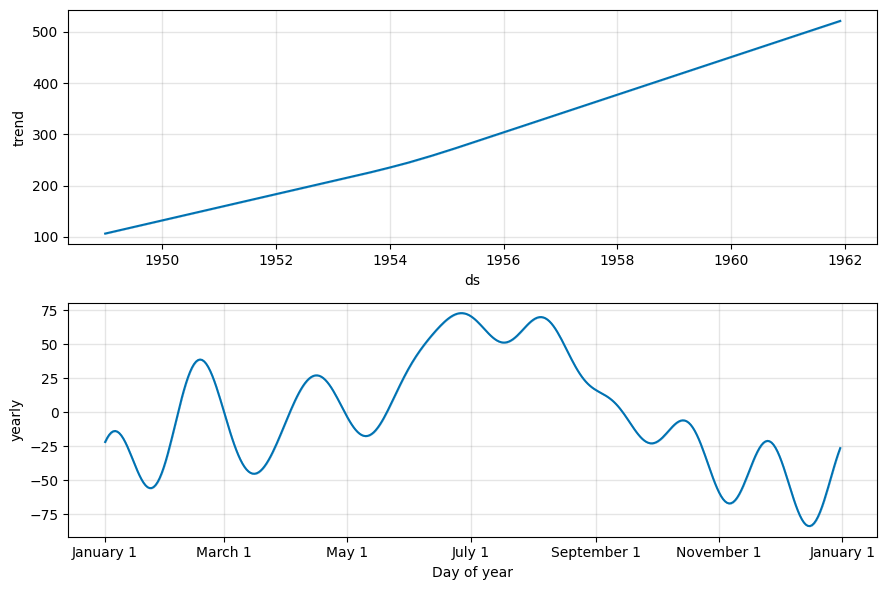

In [33]:
# Визуализация прогноза
fig1 = model_prophet.plot(forecast)
plt.title('Прогноз количества авиапассажиров')
plt.xlabel('Дата')
plt.ylabel('Количество пассажиров')
plt.show()

# Построить график компонентов прогноза
fig2 = model_prophet.plot_components(forecast)
plt.show()

In [34]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)

,ds,yhat,yhat_lower,yhat_upper
144,1960-12-31,462.225077,435.003490,489.625056
145,1961-01-31,454.904090,427.565140,481.978270
146,1961-02-28,498.092497,469.342507,525.053777
147,1961-03-31,487.910044,457.991288,517.553667
148,1961-04-30,498.586949,471.660877,526.030317
149,1961-05-31,534.164352,504.956067,566.214058
150,1961-06-30,577.307627,546.571848,606.084040
151,1961-07-31,575.744662,548.532948,603.674221
152,1961-08-31,529.327406,500.089890,556.430301
153,1961-09-30,492.512127,463.711306,521.453501


##### <b><font color='saddlebrown'>5. Решение задач</font></b>

###### <b><font color='saddlebrown'>5.1. Задача 1</font></b>
спользуя данные о продажах машин по месяцам (car_sales.csv), сделайте прогноз с использованием модели ARIMA.

In [35]:
# Загрузите данные в датафрейм df_cars
# На этапе загрузки файла сразу распарсите даты 
# и задайте нулевой столбец как индекс
df_cars = pd.read_csv('../data/car_sales.csv')
df_cars.head(10)

,Month,Sales
0,1960-01,6550
1,1960-02,8728
2,1960-03,12026
3,1960-04,14395
4,1960-05,14587
5,1960-06,13791
6,1960-07,9498
7,1960-08,8251
8,1960-09,7049
9,1960-10,9545


In [36]:
df_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Month   108 non-null    object
 1   Sales   108 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 1.8+ KB


In [37]:
df_cars['Month'] = pd.to_datetime(df_cars['Month'])

In [38]:
df_cars.set_index('Month', inplace = True)
df_cars.head(10)

,Sales
Month,
1960-01-01,6550
1960-02-01,8728
1960-03-01,12026
1960-04-01,14395
1960-05-01,14587
1960-06-01,13791
1960-07-01,9498
1960-08-01,8251
1960-09-01,7049


In [39]:
# Создайте модель ARIMA с параметрами:
# p = 5
# d = 1
# q = 0
# Назовите переменную model_cars
model_cars = ARIMA(df_cars['Sales'], order = (12, 0, 4))




c:\Users\Vitaliy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Vitaliy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Vitaliy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [40]:
# Натренируйте модель на данных и запишите результат в model_cars_fit
model_cars_fit = model_cars.fit()

c:\Users\Vitaliy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [41]:
# В переменную forecast_cars спрогнозируйте данные на 12 периодов вперед
forecast_cars = model_cars_fit.forecast(steps=12)


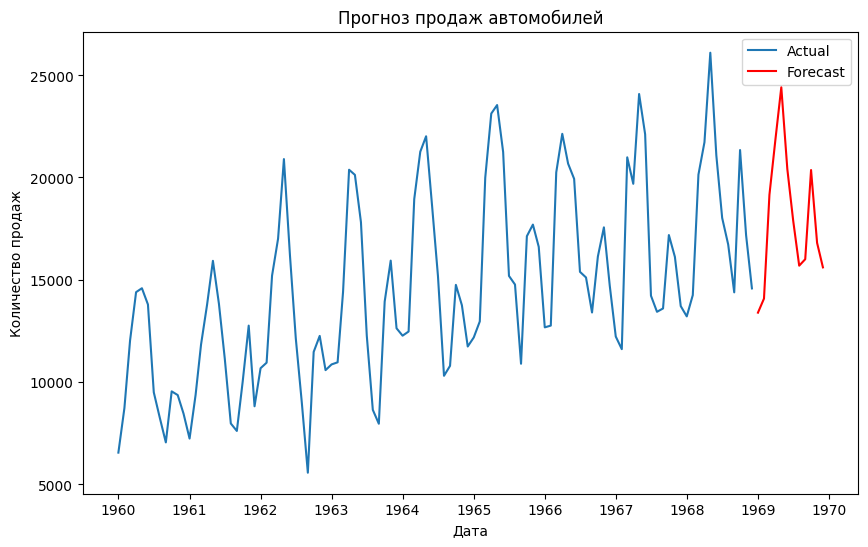

In [42]:
# Постройте график данных + прогнозы
plt.figure(figsize=(10, 6))
plt.plot(df_cars, label='Actual')
plt.plot(forecast_cars, label='Forecast', color='red')
plt.title('Прогноз продаж автомобилей')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.legend()
plt.show()

###### <b><font color='saddlebrown'>5.2. Задача 2 </font></b>
спользуя те же данные о продажах машин по месяцам , сделайте прогноз с использованием модели SARIMA.

In [43]:
# Создайте модель SARIMA с параметрами:
# p = 1
# d = 1
# q = 1
# P = 1
# D = 1
# Q = 1
# s = 12
# Назовите переменную model_cars_sarima
model_cars_sarima = SARIMAX(df_cars['Sales'], order = (1, 1, 1), seasonal_order = (1, 1, 1, 12))

c:\Users\Vitaliy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Vitaliy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [44]:
# Натренируйте модель на данных и запишите результат в model_cars_sarima_fit
model_cars_sarima_fit = model_cars_sarima.fit(disp=False)

In [45]:
# В переменную forecast_cars_sarima спрогнозируйте данные на 12 периодов вперед
forecast_cars_sarima = model_cars_sarima_fit.forecast(steps = 12)


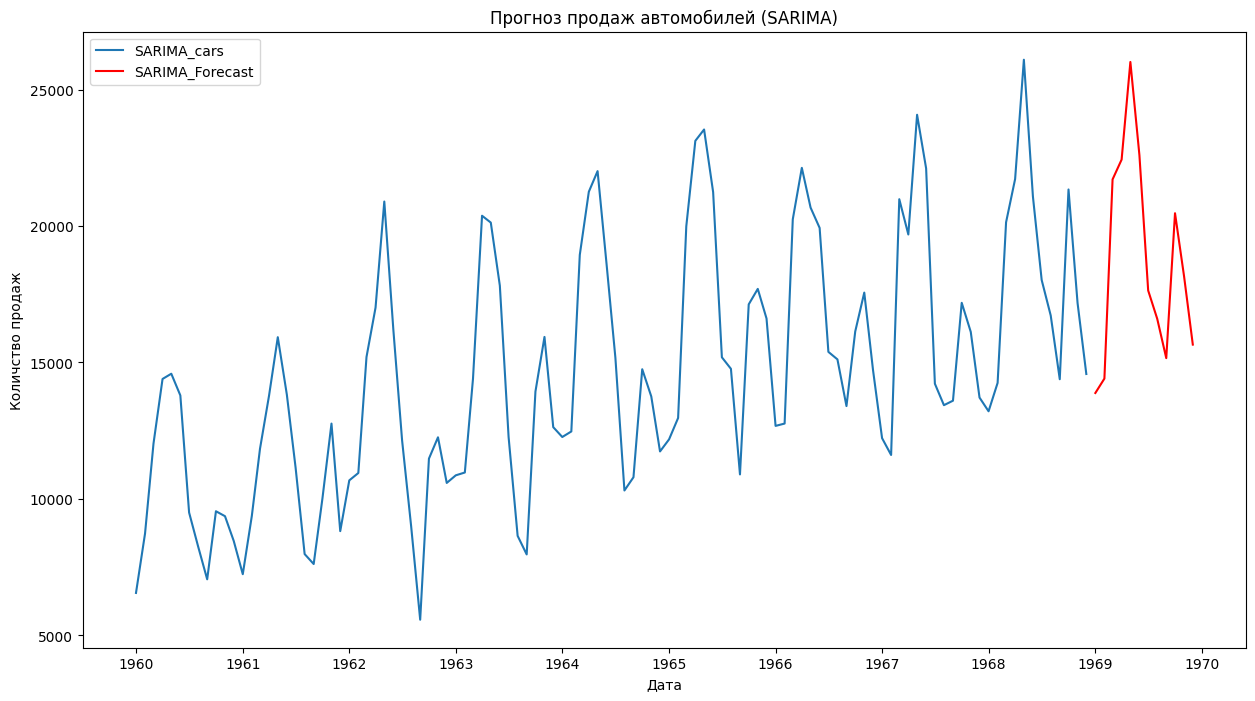

In [46]:
# Постройте график данных + прогнозы
plt.figure(figsize=(15,8))
plt.plot(df_cars, label = 'SARIMA_cars')
plt.plot(forecast_cars_sarima, label = 'SARIMA_Forecast', color = 'red')
plt.title('Прогноз продаж автомобилей (SARIMA)')
plt.xlabel('Дата')
plt.ylabel("Количство продаж")
plt.legend()
plt.show()